# NFL Big Data Bowl 2026 - Prediction
## 00 · Project identity and verified readiness

**This is the [Big Data Bowl Prediction project](https://www.kaggle.com/competitions/nfl-big-data-bowl-2026-prediction).**
A player *trajectory* is the sequence of x/y positions after the quarterback releases the pass.
The repository name `nfl-player-trajectory` describes that target; it is not a different competition.
The separate Analytics competition has a different objective and is not required here.

**Completed work is preserved.** The notebook verifies the saved real-data feature experiment
before showing a small synthetic scoring check. That demonstration is a software test, not
another training run and not a replacement for the measured NFL results.

For the employer review, continue to **01 · Data analysis** and **02 · Motion benchmarks**.
Reading these notebooks never retrains a model or submits anything to Kaggle.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from nfl_trajectory.data import COMPETITION
from nfl_trajectory.motion import KEYS, constant_velocity, trajectory_metrics
from nfl_trajectory.report import demo, synthetic_play
from nfl_trajectory.research import load_evidence
from nfl_trajectory.runtime import Run

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/nfl_trajectory").is_dir())
assert COMPETITION == "nfl-big-data-bowl-2026-prediction"
with Run(ROOT, "prediction_readiness") as run:
    evidence, selection, evidence_source = load_evidence(ROOT)
    champion = next(row for row in evidence["models"] if row["model"] == evidence["selected_model"])
    run.event(
        "prediction_evidence_verified",
        competition=COMPETITION,
        source=evidence_source,
        selected_model=evidence["selected_model"],
        validation_rmse=champion["coordinate_rmse_yards"],
        holdout_evaluation=evidence["holdout_evaluation"],
    )
print(f"Python {sys.version.split()[0]} | {COMPETITION} | report verification only")
display(Markdown(f"**Real-data evidence:** {evidence_source}. No model was refitted."))
display(
    pd.DataFrame(
        [
            {
                "Original feature-study model": evidence["selected_model"],
                "Coordinate RMSE / yards": champion["coordinate_rmse_yards"],
                "Validation games": evidence["validation_games"],
                "Validation player-frames": evidence["validation_rows_per_model"],
                "Candidate features": evidence["candidate_features"],
                "Selected correction features": champion["selected_features"],
                "Holdout evaluation": evidence["holdout_evaluation"],
            }
        ]
    ).round(4)
)
research_path = ROOT / "artifacts/research/report/summary.json"
if not research_path.exists():
    research_path = ROOT / "docs/results/feature_research.json"
if research_path.exists():
    research_status = json.loads(research_path.read_text())
    display(
        Markdown(
            f"**Expanded research bank:** {research_status['candidate_features']:,} candidates. "
            "Notebook 02 reports the newer controlled experiments and the feature completion gate."
        )
    )

{"timestamp": "2026-09-10T00:22:51.293+00:00", "run_id": "20260910T002251Z-bce40949", "event": "started", "elapsed_seconds": 0.0, "command": "prediction_readiness"}
{"timestamp": "2026-09-10T00:22:51.294+00:00", "run_id": "20260910T002251Z-bce40949", "event": "prediction_evidence_verified", "elapsed_seconds": 0.001, "competition": "nfl-big-data-bowl-2026-prediction", "source": "Published real-data experiment snapshot", "selected_model": "landing_ridge", "validation_rmse": 0.9268683891794343, "holdout_evaluation": "not_run"}
{"timestamp": "2026-09-10T00:22:51.294+00:00", "run_id": "20260910T002251Z-bce40949", "event": "completed", "elapsed_seconds": 0.001, "error_type": null}
Python 3.11.15 | nfl-big-data-bowl-2026-prediction | report verification only


**Real-data evidence:** Published real-data experiment snapshot. No model was refitted.

,Original feature-study model,Coordinate RMSE / yards,Validation games,Validation player-frames,Candidate features,Selected correction features,Holdout evaluation
0,landing_ridge,0.9269,32,67857,2843,64,not_run


**Expanded research bank:** 7,999 candidates. Notebook 02 reports the newer controlled experiments and the feature completion gate.

### 1 · Synthetic software check: scoring definition

The official metric is **coordinate RMSE**, in yards:

$$\mathrm{RMSE}=\sqrt{\frac{1}{2N}\sum_i[(x_i-\hat{x}_i)^2+(y_i-\hat{y}_i)^2]}.$$

ADE measures typical Euclidean distance; FDE measures Euclidean distance at each player's last forecast frame. We report both frame and trajectory weighting for ADE, because longer forecasts otherwise contribute more rows. A 3-yard x error and 4-yard y error gives **RMSE = √12.5**, while Euclidean distance is **5 yards**.

In [2]:
observed, actual = synthetic_play()
predicted = constant_velocity(observed, actual[KEYS])
metrics = trajectory_metrics(actual, predicted)
display(pd.DataFrame([{"metric": key, "yards": value} for key, value in metrics.items()]).round(4))
print("Data: synthetic demonstration only. These are not NFL validation results.")

Data: synthetic demonstration only. These are not NFL validation results.


,metric,yards
0,coordinate_rmse_yards,1.1909
1,ade_frame_weighted_yards,1.2703
2,ade_trajectory_weighted_yards,1.2703
3,fde_trajectory_weighted_yards,3.5410
4,p95_displacement_yards,3.3315
5,coordinate_mae_yards,0.8969


### 2 · Inspect the trajectories

The constant-velocity reference uses the last two observed frames. Its future path stays straight while these synthetic players turn. The gap is an example of the behavior a learned model must improve.

Output frame **1** means **0.1 seconds after the final observed frame**, even if the last input frame has a much larger number. We do not subtract the last input frame number from the output clock.

{"timestamp": "2026-09-10T00:22:51.402+00:00", "run_id": "20260910T002251Z-30bbb81e", "event": "started", "elapsed_seconds": 0.0, "command": "notebook_demo"}
{"timestamp": "2026-09-10T00:22:51.407+00:00", "run_id": "20260910T002251Z-30bbb81e", "event": "stage_reused", "elapsed_seconds": 0.005, "stage": "demo", "original_elapsed_seconds": 0.197}
{"timestamp": "2026-09-10T00:22:51.407+00:00", "run_id": "20260910T002251Z-30bbb81e", "event": "demo_ready", "elapsed_seconds": 0.005, "report": "artifacts/demo/trajectory.html", "metrics": {"coordinate_rmse_yards": 1.1908954719033915, "ade_frame_weighted_yards": 1.2703212534123824, "ade_trajectory_weighted_yards": 1.2703212534123822, "fde_trajectory_weighted_yards": 3.5409651663062913, "p95_displacement_yards": 3.331548399113385, "coordinate_mae_yards": 0.896875}}
{"timestamp": "2026-09-10T00:22:51.407+00:00", "run_id": "20260910T002251Z-30bbb81e", "event": "completed", "elapsed_seconds": 0.005, "error_type": null}
Interactive offline report: a

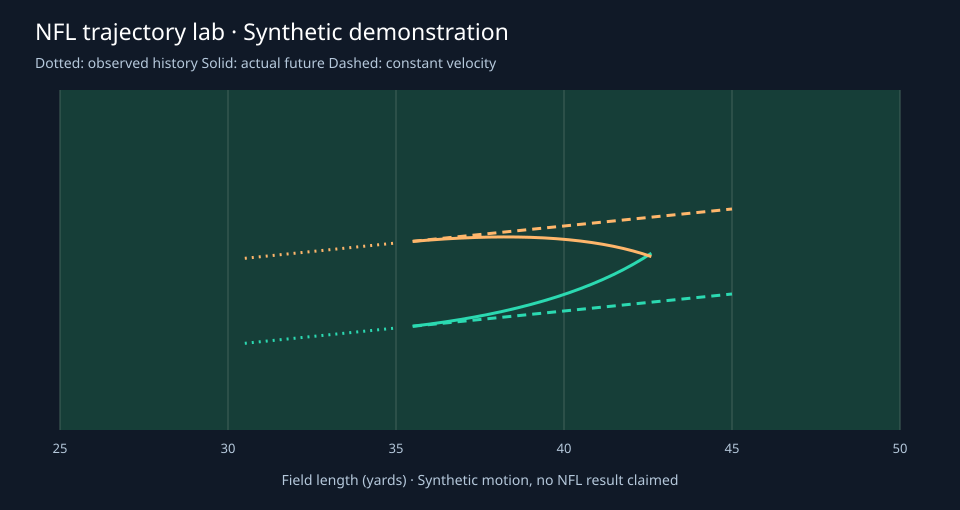

In [3]:
with Run(ROOT, "notebook_demo") as run:
    demo(ROOT, run)
from IPython.display import SVG

svg_path = ROOT / "artifacts/demo/trajectory.svg"
if svg_path.exists():
    display(SVG(filename=str(svg_path)))
print("Interactive offline report: artifacts/demo/trajectory.html")

### 3 · Distinguish local data access from completed research

The private tracking files and audit live in the SageMaker workspace and its S3 backup,
not in the public repository. A fresh Git checkout can still display and verify the
published experiment without downloading the raw data. Missing local files therefore
mean **not mounted in this checkout**, not that the completed experiment never ran.

When a local audit is present, its competition identity must match the Prediction task.

In [4]:
audit_path = ROOT / "artifacts/audit_summary.json"
if audit_path.exists():
    audit = json.loads(audit_path.read_text())
    if audit.get("competition") != COMPETITION:
        raise ValueError("Local audit belongs to a different competition; preserve and inspect it.")
    display(Markdown(f"**Local Prediction data audit: {audit['status']}**"))
    display(pd.DataFrame(audit["pairs"]).drop(columns="games"))
    display(
        pd.read_csv(ROOT / "artifacts/game_splits.csv")
        .groupby("split")
        .agg(
            games=("game_id", "count"),
            first_date=("game_date", "min"),
            last_date=("game_date", "max"),
        )
    )
else:
    display(
        Markdown(
            "**Local tracking audit is not mounted in this checkout.** "
            "The verified published real-data results above remain available. "
            "Raw tracking is intentionally excluded from Git."
        )
    )

**Local tracking audit is not mounted in this checkout.** The verified published real-data results above remain available. Raw tracking is intentionally excluded from Git.

### 4 · Know what can be used at prediction time

| Information | Use |
| --- | --- |
| Pre-throw player positions, motion, and roles | Inputs |
| Ball landing coordinates and forecast horizon | Supplied by the organizer; allowed competition inputs |
| Actual post-throw player positions | Targets only |
| Post-play outcome or statistics | Excluded from features unless availability is established |
| Future games | Validation/holdout only; never used to fit earlier-game features |

The landing location is supplied by this benchmark. A deployment that does not know it would require a different model and separate evaluation.

### 5 · Continue from the feature research evidence

The original 2,843-candidate study is the baseline shown above. The expanded study now searches **7,999 candidates across 20 families**, with chronological inner folds, fixed-estimator comparisons, strict family removals, availability tests, and wider budgets.

Open [notebook 02](02_motion_benchmarks.ipynb) for the current research findings and completion gate, then [notebook 01](01_data_analysis.ipynb) for the football hypotheses and feature provenance. A technical pipeline pass alone does not close feature engineering. Final training and the reserved holdout follow only after the evidence supports that decision.

The synthetic demonstration in this notebook tests software behavior; its score is not a real-data performance result.

Both final availability profiles have now been fitted on the combined 224-game partition and passed full-row portable conversion. Notebook 02 shows their verified counts and displays the reserved score only after its sealed evaluation has been published.